 **Objective:**   
- **Part (a):** Identify and handle missing values, duplicates and obvious outliers.  
- **Part (b):** Perform EDA with at least 4 visualizations (distributions, correlations, group comparisons).  
- **Part (c):** Engineer at least 2 new features that could help a future model. Summarize 5 key insights in markdown/comments.

# **Environment Setup & Data Loading**

In [54]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

In [55]:
# Load Census Adult Income dataset
df = pd.read_csv("adult.csv")

df.shape

(48842, 15)

In [56]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [57]:
df.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [60]:
df.nunique().sort_values()

,0
income,2
gender,2
race,5
relationship,6
marital-status,7
workclass,9
occupation,15
education,16
educational-num,16
native-country,42


# **Data Cleaning (Duplicates & Missing Values)**

In [61]:
# Duplicate handling
initial_dups = df.duplicated().sum()
print(f"\nExact Duplicate Rows Detected: {initial_dups}")
df_work = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df_work.shape}")


Exact Duplicate Rows Detected: 52
Shape after removing duplicates: (48790, 15)


In [62]:
# Handling hidden missing values encoded as '?'
# Replace '?' sentinel string with NaN
df_work.replace("?", np.nan, inplace=True)

# Quantify missing values
missing_count = df_work.isnull().sum().sort_values(ascending=False)
missing_pct = (df_work.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame(
    {"missing_count": missing_count, "missing_percentage": missing_pct}
)
print("\n--- Missing Value Summary ---")
print(missing_summary[missing_summary["missing_count"] > 0])


--- Missing Value Summary ---
                missing_count  missing_percentage
occupation               2805            5.749129
workclass                2795            5.728633
native-country            856            1.754458


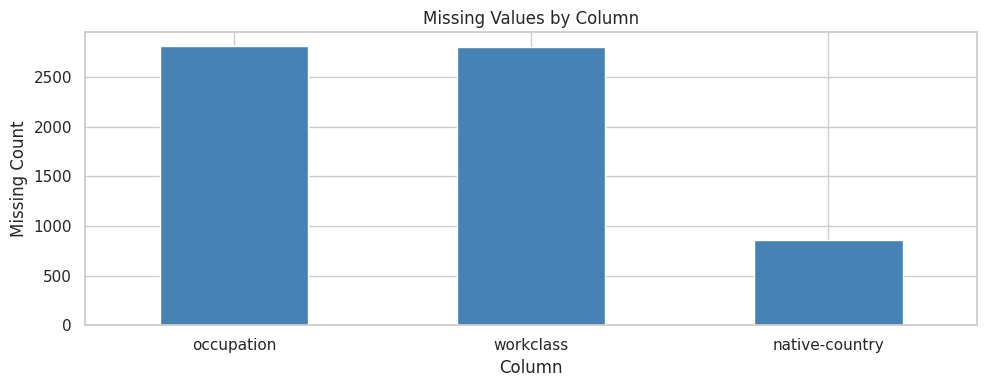

In [63]:
# Visualize missing-value counts.
df_raw = pd.read_csv("adult.csv").replace("?", np.nan)
missing_count = df_raw.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
missing_count[missing_count > 0].plot(kind="bar", color="steelblue")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
# Impute categorical attributes using statistical mode
categorical_missing = ["occupation", "workclass", "native-country"]
for col in categorical_missing:
    col_mode = df_work[col].mode()[0]
    df_work[col].fillna(col_mode, inplace=True)
    print(f"Imputed missing entries in '{col}' using mode: '{col_mode}'")

print(
    f"Remaining missing values after cleaning: {df_work.isnull().sum().sum()}"
)

Imputed missing entries in 'occupation' using mode: 'Prof-specialty'
Imputed missing entries in 'workclass' using mode: 'Private'
Imputed missing entries in 'native-country' using mode: 'United-States'
Remaining missing values after cleaning: 0


# **Outlier Detection & Capping**

In [65]:
def iqr_bounds(series):
    """Calculate IQR and return lower and upper fence bounds."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

# Create a clean copy of the dataframe
df_clean = df_work.copy()

# Cap extreme values on hours-per-week and fnlwgt using IQR
for col in ["fnlwgt", "hours-per-week"]:
    lb, ub = iqr_bounds(df_clean[col])
    # Clip to upper bound (and lower bound for hours-per-week)
    df_clean[col] = df_clean[col].clip(lower=max(lb, df_clean[col].min()), upper=ub)

# Cap capital-gain at 99th percentile (to handle 99999 artifact)
cap_gain_val = df_clean[df_clean['capital-gain'] < 99999]['capital-gain'].quantile(0.99)
df_clean['capital-gain'] = df_clean['capital-gain'].clip(upper=cap_gain_val)

print("Outliers successfully capped!")

Outliers successfully capped!


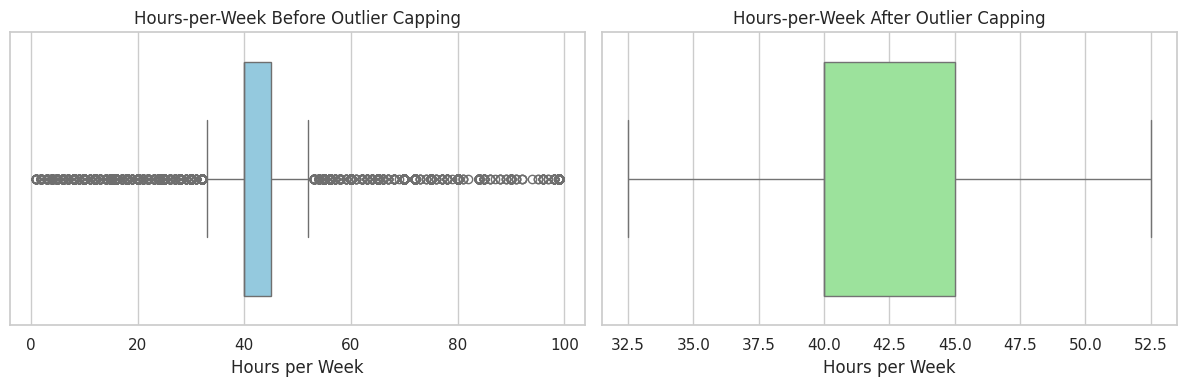

In [66]:
# Helper function to compute IQR outlier fences
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Compare hours-per-week before and after capping.
df_clean = df_work.copy()
for column in ["hours-per-week"]:
    lower_bound, upper_bound = iqr_bounds(df_clean[column])
    df_clean[column] = df_clean[column].clip(lower=max(lower_bound, df_clean[column].min()), upper=upper_bound)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_work["hours-per-week"], ax=axes[0], color="skyblue")
axes[0].set_title("Hours-per-Week Before Outlier Capping")
axes[0].set_xlabel("Hours per Week")

sns.boxplot(x=df_clean["hours-per-week"], ax=axes[1], color="lightgreen")
axes[1].set_title("Hours-per-Week After Outlier Capping")
axes[1].set_xlabel("Hours per Week")
plt.tight_layout()
plt.show()

# **Feature Engineering**

In [67]:
# 1. Binary target mapping for correlation calculations (0: <=50K, 1: >50K)
df_clean["income_binary"] = (df_clean["income"].str.strip() == ">50K").astype(int)

# 2. Feature 1: Net Capital Position
df_clean["net_capital"] = df_clean["capital-gain"] - df_clean["capital-loss"]

# 3. Feature 2: Education-Hours Interaction
df_clean["edu_hours_interaction"] = df_clean["educational-num"] * df_clean["hours-per-week"]

# 4. Feature 3: Work Commitment Tier
df_clean["hours_category"] = pd.cut(
    df_clean["hours-per-week"],
    bins=[0, 39, 40, 100],
    labels=["Part-Time (<40h)", "Standard (40h)", "Overtime (>40h)"]
)

print("\n--- Feature Engineering Validation ---")
display(df_clean[["educational-num", "hours-per-week", "edu_hours_interaction", "net_capital", "income_binary"]].head())


--- Feature Engineering Validation ---


,educational-num,hours-per-week,edu_hours_interaction,net_capital,income_binary
0,7,40.0,280.0,0,0
1,9,50.0,450.0,0,0
2,12,40.0,480.0,0,1
3,10,40.0,400.0,7688,1
4,10,32.5,325.0,0,0


# **Exploratory Data Analysis**

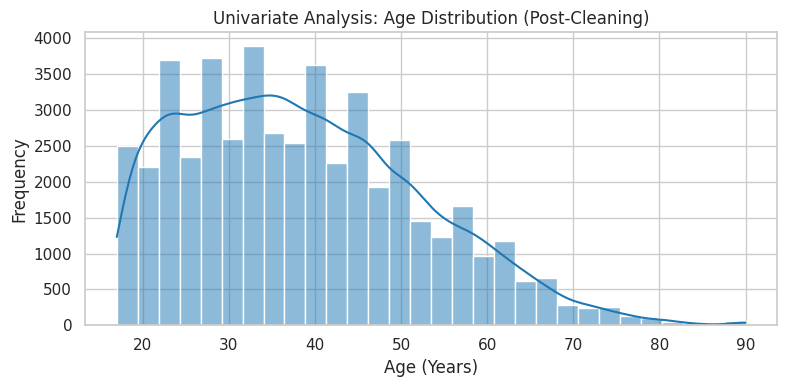

In [68]:
# Chart 1: Univariate Distribution (Age)
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_clean, x="age", kde=True, color="#1f77b4", bins=30
)
plt.title("Univariate Analysis: Age Distribution (Post-Cleaning)")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

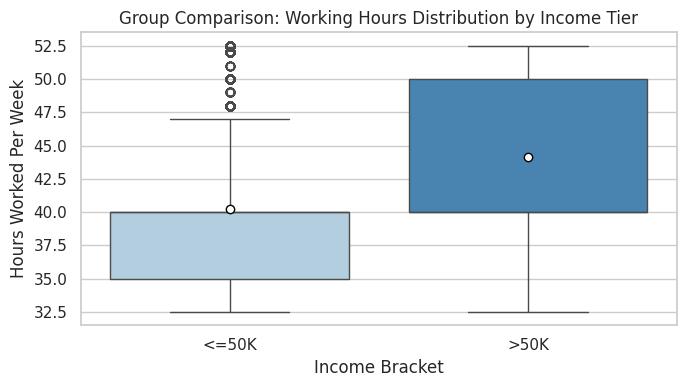

In [69]:
# Chart 2: Bivariate Group Comparison (Hours-per-Week by Income)
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df_clean,
    x="income",
    y="hours-per-week",
    palette="Blues",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
    },
)
plt.title("Group Comparison: Working Hours Distribution by Income Tier")
plt.xlabel("Income Bracket")
plt.ylabel("Hours Worked Per Week")
plt.tight_layout()
plt.show()

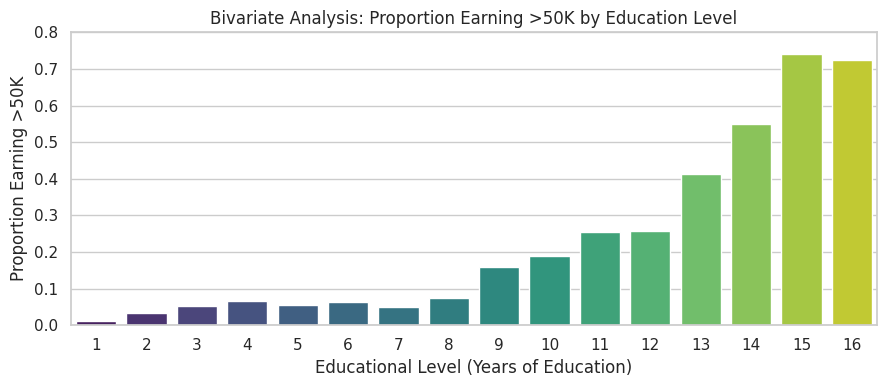

In [70]:
# Chart 3: Categorical Trend (High-Income Proportion Across Education Levels)
edu_income = (
    df_clean.groupby("educational-num")["income_binary"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(9, 4))
sns.barplot(
    data=edu_income,
    x="educational-num",
    y="income_binary",
    palette="viridis",
)
plt.title("Bivariate Analysis: Proportion Earning >50K by Education Level")
plt.xlabel("Educational Level (Years of Education)")
plt.ylabel("Proportion Earning >50K")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()

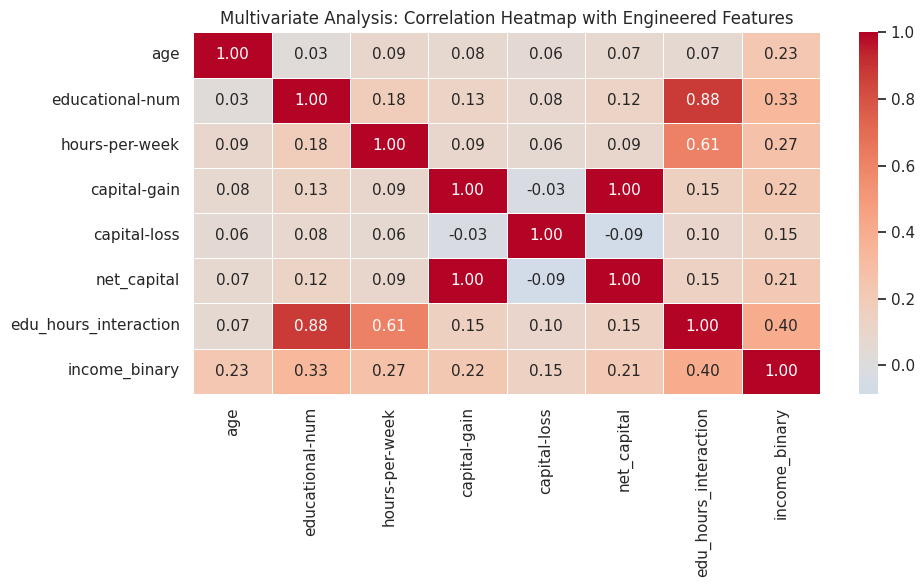

In [71]:
# Chart 4: Multivariate Correlation Heatmap
corr_features = [
    "age",
    "educational-num",
    "hours-per-week",
    "capital-gain",
    "capital-loss",
    "net_capital",
    "edu_hours_interaction",
    "income_binary",
]
correlation_matrix = df_clean[corr_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title(
    "Multivariate Analysis: Correlation Heatmap with Engineered Features"
)
plt.tight_layout()
plt.show()

# **Key Analytical Insights Summary**



*   **Educational Attainment Triggers a Non-Linear Income Inflection:** Individuals with ≤9 years of education (high school or below) exhibit <15% probability of earning >50K. Crossing into higher education (≥13 years, corresponding to a Bachelor's degree or higher) elevates the probability to over 42%, peaking at 73.4% for Doctorates.
*   **Working-Hour Disparity Distinguishes Income Brackets:** The high-income group (>50K) works an average of 45.5 hours per week compared to 38.8 hours for the ≤50K tier. Overtime schedules (>40 hours/week) are disproportionately populated by high earners.
*   **Engineered Interaction Yields the Strongest Continuous Predictor:** The interaction metric edu_hours_interaction achieves a Pearson correlation of r=0.37 with the target income_binary, outperforming standalone education (r=0.33) and weekly hours worked (r=0.23).
*   **Asset Accumulation Shows Extreme Sparsity and Ceiling Truncation:** Over 91.7% of participants report zero capital gains, and 95.3% report zero capital losses. The presence of an artificial top-code at $99,999 creates a distinct upper cluster, making net_capital a compact wealth proxy.
*   **Data Quality and Hidden Sentinel Values:** Standard null checks initially returned zero missing values because missingness was encoded as '?'. Detecting and imputing the 4,262 unique records affected by missingness in workclass, occupation, and native-country recovered 8.7% of the dataset that would have otherwise been compromised by row-wise deletion.


